# Session-Level PCA Population Analysis

This notebook demonstrates PCA analysis of MSN cell populations of a single session using the `Session` class.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import holoviews as hv
import hvplot.pandas
from pathlib import Path
from holoviews import opts
from bokeh.io import output_notebook
from bokeh.palettes import Plasma256
import sys

# Add parent directory to path to import Cell and PopulationAnalyzer
sys.path.append(str(Path.cwd()))

font_dict = {'title': 16, 'labels': 14, 'ticks': 12, 'legend': 12}
hv.opts.defaults(
    hv.opts.Curve(width=800, height=400, tools=['hover'], fontsize=font_dict),
    hv.opts.Image(width=800, height=600, tools=['hover'], cmap='Plasma', colorbar=True, fontsize=font_dict),
)

output_notebook()
hv.extension('bokeh')

print("Imports loaded successfully!")

Loading BokehJS ...

Imports loaded successfully!


In [2]:
# Load MSN cell database
monkey = 'fiona'  # 'yasmin' or 'fiona'

base_path = Path.cwd().parent / 'data' / 'unified_cell_trial_data' 
pickle_file = base_path / f'msn_{monkey}_cell_trial_data.pkl'

cell_df = pd.read_pickle(pickle_file)

In [3]:
cell_df.shape

(1906402, 27)

In [4]:
# Add parent directory to path to import Cell and PopulationAnalyzer
sys.path.insert(0, str(Path.cwd().parent))
import importlib
import session_class
import cell_analysis
importlib.reload(session_class)
importlib.reload(cell_analysis)
from session_class import Session
from cell_analysis import Cell, PopulationAnalyzer

print("Cell, PopulationAnalyzer, and Session classes imported successfully!")

Cell, PopulationAnalyzer, and Session classes imported successfully!


In [5]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

def pca_mat(mat, pca_components=5):
    # scaler = StandardScaler()
    # mat_for_pca = scaler.fit_transform(mat.T)
    mat_for_pca = mat.T
    pca = PCA(n_components=pca_components)
    pca.fit(mat_for_pca)
    return pca

In [6]:
# Select a session to analyze - use session with most cells
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique().sort_values(ascending=False)
best_session_id = session_cell_counts.index[0]

print(f"Using session with most cells: {best_session_id}")
print(f"Number of cells in this session: {session_cell_counts.iloc[0]}")

# Get all data for this session
session_data = cell_df[cell_df['trial_session'] == best_session_id]

# Create Session object
session = Session(session_data, verbose=True)

Using session with most cells: fi211102a
Number of cells in this session: 185
Session fi211102a initialized:
  - Number of cells: 185
  - Total trials: 1813
  - Trial types: ['CONT', 'GO', 'STOP']
  - Directions: [np.int64(0), np.int64(180)]


In [7]:
go_data = session.get_population_PSTHs_left_right(
    epok=[-100, 200],
    bin_size=1,
    alignment_point='stop_cue',
    trial_type='GO',
    success_only=True,
    smooth=True,
    smooth_ker_size=25,
    delta=True,
    normalize_bins=False,
    normalize='by_baseline_FR',
    sort_by_peak=False
)

In [8]:
go_data['left']['psth_matrix'].shape


(185, 300)

In [9]:
session.drop_cells_with_missing_trial_type_or_dir_data()    

In [10]:
epok = [-50, 300]
bin_size = 1
alignment_point = 'go_cue'
smooth_ker_size = 15
normalize = 'by_baseline_FR'

avg_psth = session.get_population_PSTH_single_condition(
    epok=epok,
    bin_size=bin_size,
    alignment_point=alignment_point,
    trial_type='GO',
    success_only=True,
    smooth=True,
    smooth_ker_size=smooth_ker_size, 
    delta=True,
    normalize_bins=False,
    normalize=normalize,
    sort_by_peak=False
)
avg_psth['psth_matrix'].shape

(185, 350)

In [11]:
cell = session.get_cell(session.cell_ids[0])
cell
bins, fr, n_cells = cell.calculate_psth(
    epok=epok,
    bin_size=bin_size,
    alignment_point=alignment_point,
    trial_type='GO',
    success_only=True,
    smooth=True,
    smooth_ker_size=smooth_ker_size, 
    delta=True,
    normalize_bins=False,
)
fr.shape

(350,)

In [12]:
train_session, test_session = session.split_to_train_test(
    test_fraction=0.5, random_state=42
)
train_session, test_session

(Session fi211102a | Cells: 185 | Trials: 1810 | Trial Types: ['CONT', 'GO', 'STOP'] | Directions: [np.int64(0), np.int64(180)],
 Session fi211102a | Cells: 185 | Trials: 1812 | Trial Types: ['CONT', 'GO', 'STOP'] | Directions: [np.int64(0), np.int64(180)])

In [13]:
def get_data_patrix_for_PCA(session: Session, epok=[-200, 500]) -> np.ndarray:
    left_right_for_PCA = train_session.get_population_PSTHs_left_right(
        epok=epok,
        bin_size=bin_size,
        alignment_point=alignment_point,
        trial_type='GO',
        success_only=True,
        smooth=True,
        smooth_ker_size=smooth_ker_size, 
        delta=True,
        normalize_bins=False,
        normalize=normalize,
        sort_by_peak=False
    )

    left = left_right_for_PCA['left']['psth_matrix'] #- avg_psth['psth_matrix']
    right = left_right_for_PCA['right']['psth_matrix'] #- avg_psth['psth_matrix']

    psth_matrix = np.concatenate([left, right], axis=1)
    return psth_matrix

# Create PCA instance using training session data
pca = pca_mat(
    get_data_patrix_for_PCA(train_session, epok=epok)
)

# Transform test session data using the trained PCA
res = pca.transform(
    get_data_patrix_for_PCA(test_session, epok=epok).T
).T

In [14]:
pca.explained_variance_ratio_
cutoff = epok[1] - epok[0]
left_PCs = res[:, :cutoff]
right_PCs = res[:, cutoff:]
time = np.arange(epok[0], epok[1])

In [15]:
# Create stop trial data projections
left_right_STOP_for_PCA = test_session.get_population_PSTHs_left_right(
    epok=epok,
    bin_size=bin_size,
    alignment_point=alignment_point,
    trial_type='STOP',
    success_only=True,
    ssd_number=1,
    smooth=True,
    smooth_ker_size=smooth_ker_size, 
    delta=True,
    normalize_bins=False,
    normalize=normalize,
    sort_by_peak=False
)
left_right_STOP_for_PCA.keys()

left = left_right_STOP_for_PCA['left']['psth_matrix'] #- avg_psth['psth_matrix']
right = left_right_STOP_for_PCA['right']['psth_matrix'] #- avg_psth['psth_matrix']

stop_psth_matrix = np.concatenate([left, right], axis=1)

stop_res = pca.transform(stop_psth_matrix.T).T
stop_res.shape
stop_left_PCs = stop_res[:, :cutoff]
stop_right_PCs = stop_res[:, cutoff:]
stop_res.shape, stop_left_PCs.shape, stop_right_PCs.shape

((5, 700), (5, 350), (5, 350))

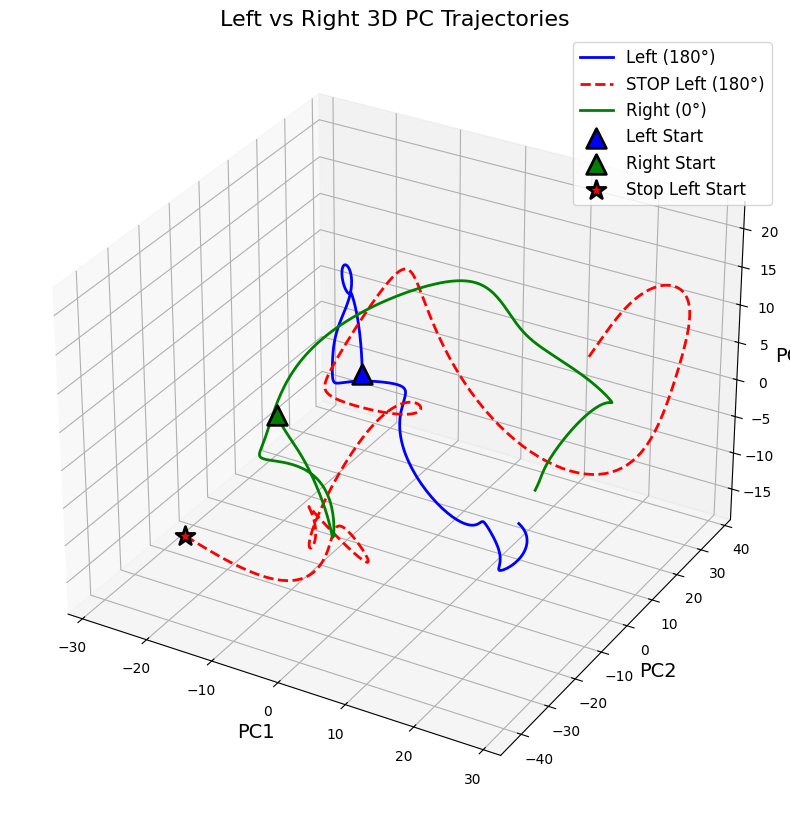

In [16]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
# ax = fig.add_subplot(111)

# Plot left trajectory (180°)
ax.plot(left_PCs[0, :], left_PCs[1, :], left_PCs[2, :], 
    color='blue', linewidth=2, label='Left (180°)')

# Plot left STOP trajectory (180°)
ax.plot(stop_left_PCs[0, :], stop_left_PCs[1, :], stop_left_PCs[2, :], 
    color='red', linewidth=2, label='STOP Left (180°)', linestyle='dashed')

# Plot right trajectory (0°)
ax.plot(right_PCs[0, :], right_PCs[1, :], right_PCs[2, :], 
    color='green', linewidth=2, label='Right (0°)')

# Plot right STOP trajectory (0°)
# ax.plot(stop_right_PCs[0, :], stop_right_PCs[1, :], #stop_right_PCs[2, :], 
#     color='yellow', linewidth=2, label='STOP Right (0°)', linestyle='dashed')

# Mark start points with triangles
ax.scatter(left_PCs[0, 0], left_PCs[1, 0], left_PCs[2, 0], 
    marker='^', s=200, color='blue', edgecolors='black', linewidths=2, 
    label='Left Start', zorder=5)

ax.scatter(right_PCs[0, 0], right_PCs[1, 0], right_PCs[2, 0], 
    marker='^', s=200, color='green', edgecolors='black', linewidths=2, 
    label='Right Start', zorder=5)

ax.scatter(stop_left_PCs[0, 0], stop_left_PCs[1, 0], stop_left_PCs[2, 0], 
    marker='*', s=200, color='red', edgecolors='black', linewidths=2, 
    label='Stop Left Start', zorder=5)

# ax.scatter(stop_right_PCs[0, 0], stop_right_PCs[1, 0], #stop_right_PCs[2, 0], 
#     marker='*', s=200, color='green', edgecolors='black', linewidths=2, 
#     label='Stop Right Start', zorder=5)


# Labels and title
ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
ax.set_zlabel('PC3', fontsize=14)
ax.set_title('Left vs Right 3D PC Trajectories', fontsize=16)
ax.legend(fontsize=12)



In [17]:
np.save('../data/PCA_data/left_PCs', left_PCs, allow_pickle=False)
np.save('../data/PCA_data/right_PCs', right_PCs, allow_pickle=False)
np.save('../data/PCA_data/stop_left_PCs', stop_left_PCs, allow_pickle=False)
np.save('../data/PCA_data/stop_right_PCs', stop_right_PCs, allow_pickle=False)


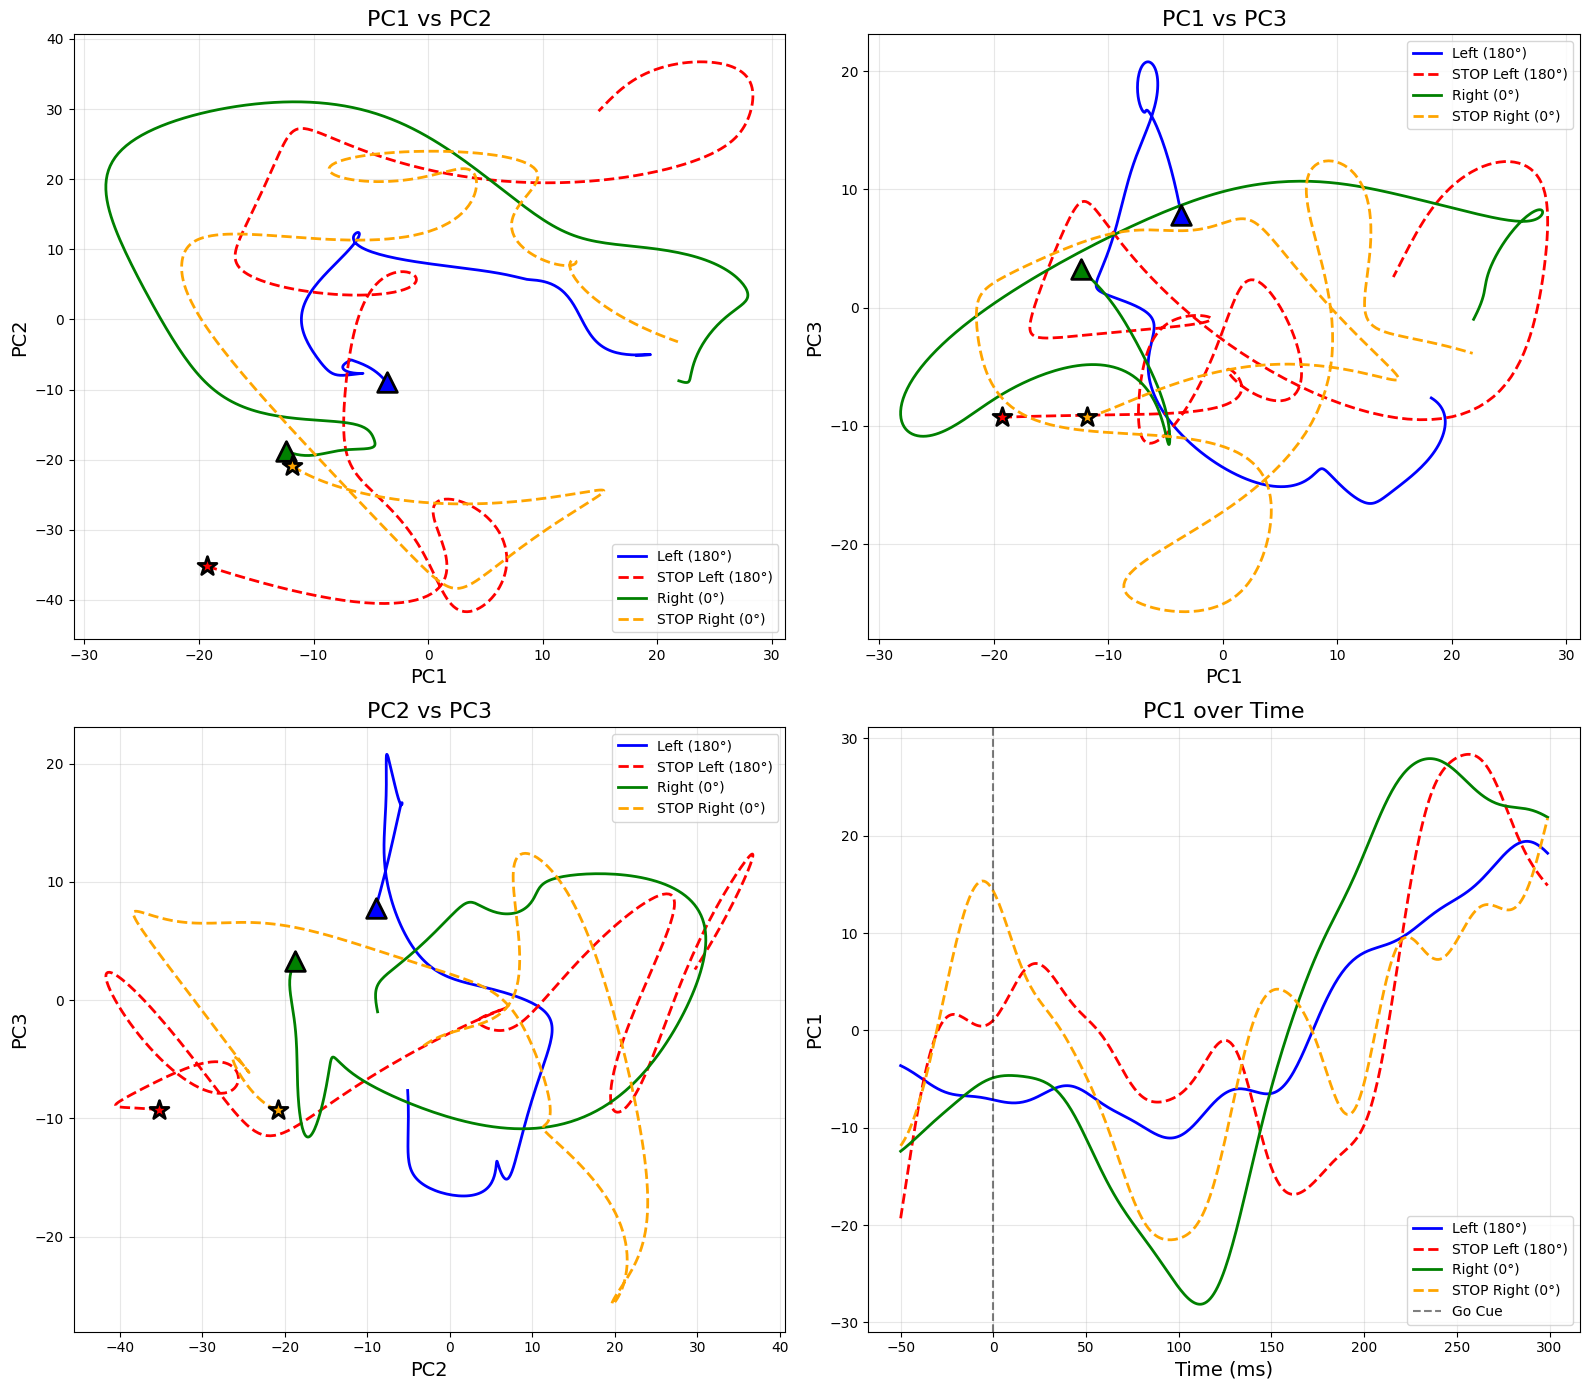

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

# Plot PC1 vs PC2
ax = axes[0, 0]
ax.plot(left_PCs[0, :], left_PCs[1, :], color='blue', linewidth=2, label='Left (180°)')
ax.plot(stop_left_PCs[0, :], stop_left_PCs[1, :], color='red', linewidth=2, label='STOP Left (180°)', linestyle='dashed')
ax.plot(right_PCs[0, :], right_PCs[1, :], color='green', linewidth=2, label='Right (0°)')
ax.plot(stop_right_PCs[0, :], stop_right_PCs[1, :], color='orange', linewidth=2, label='STOP Right (0°)', linestyle='dashed')
ax.scatter(left_PCs[0, 0], left_PCs[1, 0], marker='^', s=200, color='blue', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(right_PCs[0, 0], right_PCs[1, 0], marker='^', s=200, color='green', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(stop_left_PCs[0, 0], stop_left_PCs[1, 0], marker='*', s=200, color='red', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(stop_right_PCs[0, 0], stop_right_PCs[1, 0], marker='*', s=200, color='orange', edgecolors='black', linewidths=2, zorder=5)
ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
ax.set_title('PC1 vs PC2', fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot PC1 vs PC3
ax = axes[0, 1]
ax.plot(left_PCs[0, :], left_PCs[2, :], color='blue', linewidth=2, label='Left (180°)')
ax.plot(stop_left_PCs[0, :], stop_left_PCs[2, :], color='red', linewidth=2, label='STOP Left (180°)', linestyle='dashed')
ax.plot(right_PCs[0, :], right_PCs[2, :], color='green', linewidth=2, label='Right (0°)')
ax.plot(stop_right_PCs[0, :], stop_right_PCs[2, :], color='orange', linewidth=2, label='STOP Right (0°)', linestyle='dashed')
ax.scatter(left_PCs[0, 0], left_PCs[2, 0], marker='^', s=200, color='blue', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(right_PCs[0, 0], right_PCs[2, 0], marker='^', s=200, color='green', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(stop_left_PCs[0, 0], stop_left_PCs[2, 0], marker='*', s=200, color='red', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(stop_right_PCs[0, 0], stop_right_PCs[2, 0], marker='*', s=200, color='orange', edgecolors='black', linewidths=2, zorder=5)
ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC3', fontsize=14)
ax.set_title('PC1 vs PC3', fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot PC2 vs PC3
ax = axes[1, 0]
ax.plot(left_PCs[1, :], left_PCs[2, :], color='blue', linewidth=2, label='Left (180°)')
ax.plot(stop_left_PCs[1, :], stop_left_PCs[2, :], color='red', linewidth=2, label='STOP Left (180°)', linestyle='dashed')
ax.plot(right_PCs[1, :], right_PCs[2, :], color='green', linewidth=2, label='Right (0°)')
ax.plot(stop_right_PCs[1, :], stop_right_PCs[2, :], color='orange', linewidth=2, label='STOP Right (0°)', linestyle='dashed')
ax.scatter(left_PCs[1, 0], left_PCs[2, 0], marker='^', s=200, color='blue', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(right_PCs[1, 0], right_PCs[2, 0], marker='^', s=200, color='green', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(stop_left_PCs[1, 0], stop_left_PCs[2, 0], marker='*', s=200, color='red', edgecolors='black', linewidths=2, zorder=5)
ax.scatter(stop_right_PCs[1, 0], stop_right_PCs[2, 0], marker='*', s=200, color='orange', edgecolors='black', linewidths=2, zorder=5)
ax.set_xlabel('PC2', fontsize=14)
ax.set_ylabel('PC3', fontsize=14)
ax.set_title('PC2 vs PC3', fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot time vs PC1
ax = axes[1, 1]
ax.plot(time, left_PCs[0, :], color='blue', linewidth=2, label='Left (180°)')
ax.plot(time, stop_left_PCs[0, :], color='red', linewidth=2, label='STOP Left (180°)', linestyle='dashed')
ax.plot(time, right_PCs[0, :], color='green', linewidth=2, label='Right (0°)')
ax.plot(time, stop_right_PCs[0, :], color='orange', linewidth=2, label='STOP Right (0°)', linestyle='dashed')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Go Cue')
ax.set_xlabel('Time (ms)', fontsize=14)
ax.set_ylabel('PC1', fontsize=14)
ax.set_title('PC1 over Time', fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

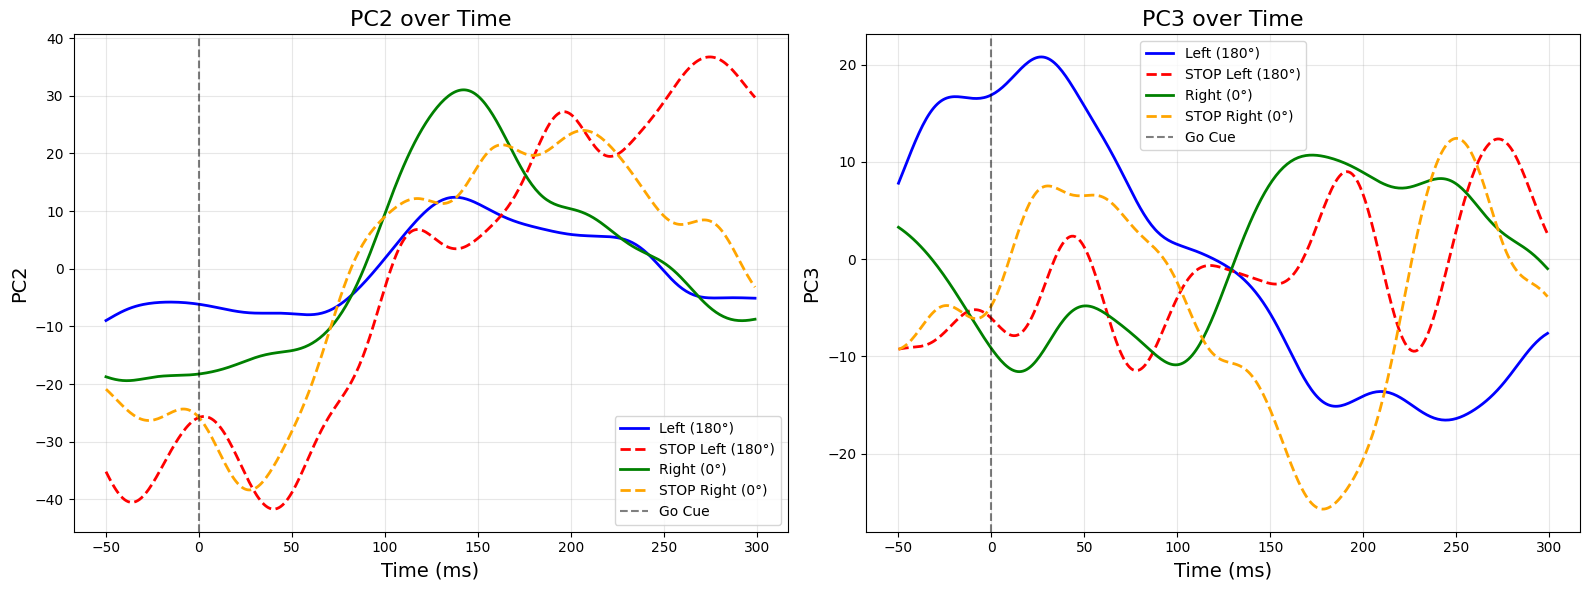

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot PC2 over time
ax = axes[0]
ax.plot(time, left_PCs[1, :], color='blue', linewidth=2, label='Left (180°)')
ax.plot(time, stop_left_PCs[1, :], color='red', linewidth=2, label='STOP Left (180°)', linestyle='dashed')
ax.plot(time, right_PCs[1, :], color='green', linewidth=2, label='Right (0°)')
ax.plot(time, stop_right_PCs[1, :], color='orange', linewidth=2, label='STOP Right (0°)', linestyle='dashed')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Go Cue')
ax.set_xlabel('Time (ms)', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
ax.set_title('PC2 over Time', fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# Plot PC3 over time
ax = axes[1]
ax.plot(time, left_PCs[2, :], color='blue', linewidth=2, label='Left (180°)')
ax.plot(time, stop_left_PCs[2, :], color='red', linewidth=2, label='STOP Left (180°)', linestyle='dashed')
ax.plot(time, right_PCs[2, :], color='green', linewidth=2, label='Right (0°)')
ax.plot(time, stop_right_PCs[2, :], color='orange', linewidth=2, label='STOP Right (0°)', linestyle='dashed')
ax.axvline(x=0, color='black', linestyle='--', alpha=0.5, label='Go Cue')
ax.set_xlabel('Time (ms)', fontsize=14)
ax.set_ylabel('PC3', fontsize=14)
ax.set_title('PC3 over Time', fontsize=16)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()